# Day 4

### **Importing**

In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv('../../week1/day4/train.csv')
age = data['Age']
fare = data['Fare']
print(age.info())
print(fare.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
age = age.fillna(age.median())
print(age.isna().sum())


0


### Step 1: Load a provided real dataset and produce a histogram for each numeric variable.

<Axes: xlabel='Age', ylabel='Count'>

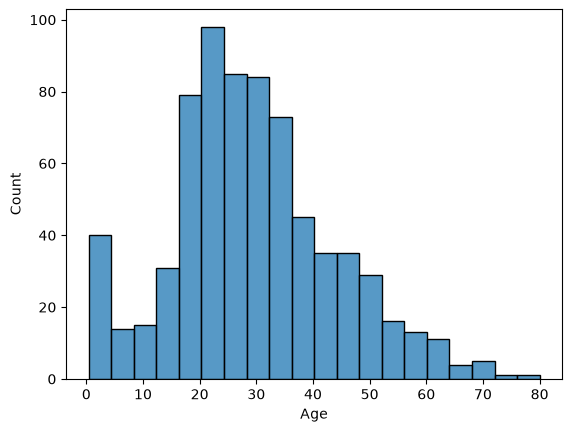

In [11]:
sns.histplot(data=data,x='Age')

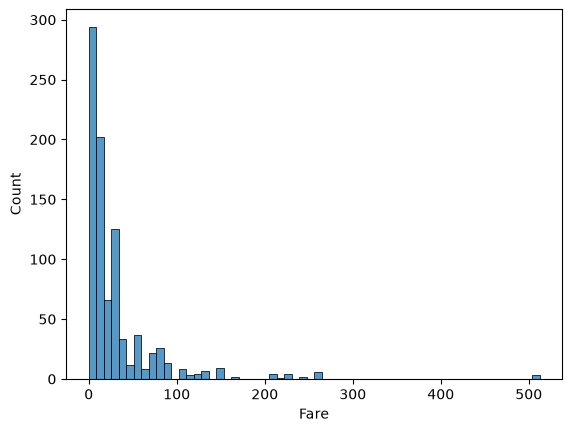

In [ ]:
sns.histplot(data=data,x='Fare')

### Step 2: Produce a box plot for the key numeric variables and identify any outliers visually.

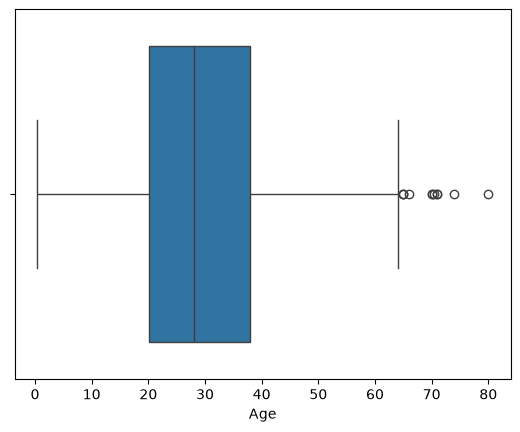

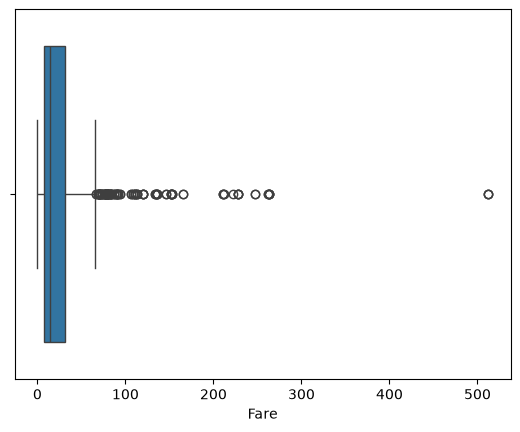

In [17]:
sns.boxplot(data=data,x="Age")
plt.show()
sns.boxplot(data=data,x="Fare")
plt.show()


#### Step 3: Apply the IQR method in code to flag outliers in at least one column, and decide (with justification) 
#### how to handle them.

In [24]:
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = age[
    (age < lower_bound) |
    (age > upper_bound)
]

print(outliers)
print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

33     66.0
54     65.0
96     71.0
116    70.5
280    65.0
456    65.0
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64
Q1 = 20.125
Q3 = 38.0
IQR = 17.875
Lower Bound = -6.6875
Upper Bound = 64.8125


I applied the IQR to the **age** column in the **Titanic dataset** and the outliers was normal its just the passengers with values more than 64, which is not an error or an unexpected behavior no its normal, but I search and seen that the majority of the passengers was between **20 - 40**, so am not thinking of remove or do anything to them

### Step 4: Produce a count plot for each categorical variable and note any class imbalance.

<Axes: xlabel='Sex', ylabel='count'>

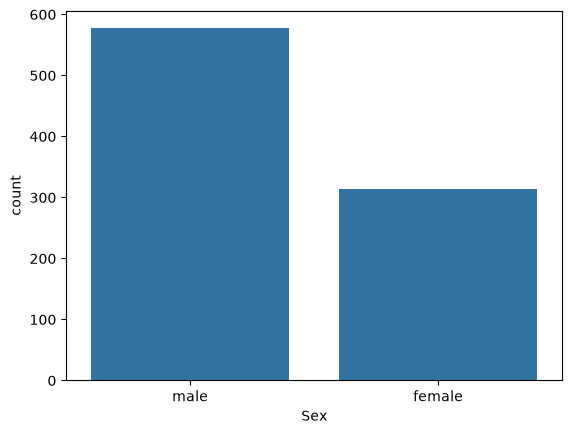

In [28]:
sns.countplot(data=data,x='Sex')

The win was for the male team **(as usual)** it was like **580 - 599**, and the female team was like **300**

### Step 5: Document what each distribution reveals in Markdown cells.

#### Age Distribution
The histogram shows that most passengers were between **20 and 40 years old**, with fewer passengers at older ages. After applying the IQR method, passengers older than approximately **65 years** were flagged as outliers. However, these values are realistic and represent elderly passengers rather than data errors, so they were kept in the dataset.

#### Fare Distribution
The fare distribution is **highly right-skewed**. Most passengers paid relatively low fares, while a small number paid significantly higher amounts. The box plot shows several high-fare outliers, which are likely genuine first-class ticket prices rather than incorrect values.

#### Age Box Plot
The box plot confirms that the age distribution contains only a small number of outliers. Since these ages are valid and expected in a real-world passenger dataset, they should not be removed without further justification.

#### Fare Box Plot
The fare box plot contains many outliers above the upper whisker. These represent passengers who paid unusually expensive fares. Because these values are reasonable, they should be investigated before deciding whether to keep.

#### Sex Count Plot
The count plot shows that the dataset contains noticeably more **male** passengers than **female** passengers. This indicates a class imbalance in the `Sex` feature, with males making up the majority of the dataset.